# Validating PWP Signal for long-exposure probe simulations 

In [1]:
# Package inputs
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import proper
import roman_preflight_proper
from corgisim import scene, instrument
from tqdm import tqdm
from pathlib import Path
from astropy.io import fits

/home/jarenashcraft/anaconda3/envs/corgi/lib/python3.12/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/jarenashcraft/.var/app/com.vscodium.codium/config', but the default location, /home/jarenashcraft/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


In [2]:
# USER INPUTS
star_choice = "Beta Car" # must be in 'starlist'
cr_rate = 0 # Keeping zero for purposes of this simulation
contrast = 3e-8
use_probe = 1 # 0, 1

assert contrast in [1e-5, 2e-7, 3e-8, 5e-9, 2e-9]
assert use_probe in [0, 1]

# Load and scale the probes according to contrast

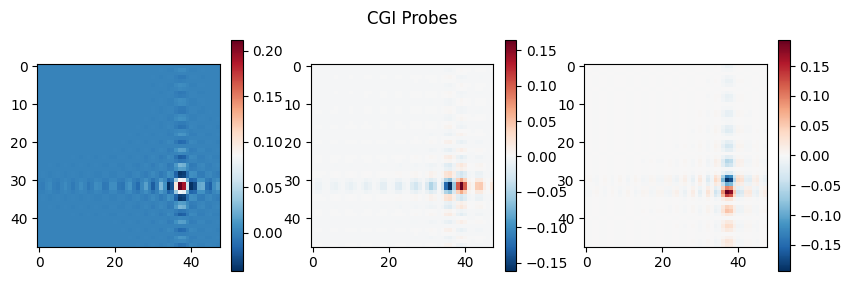

In [3]:
# Load the probe offices
PROBE_SELECT = 1
probepath = Path.home() / 'corgihowfsc/corgihowfsc/model/probes'
probe0file = probepath / 'nfov_dm_dmrel_4_1.0e-05_cos.fits'
probe1file = probepath / 'nfov_dm_dmrel_4_1.0e-05_sinlr.fits'
probe2file = probepath / 'nfov_dm_dmrel_4_1.0e-05_sinud.fits'

# Get the scaling from cgi-howfsc
scaling = {
    1e-5: 1.,
    2e-7: 1 / np.sqrt(10),
    3e-8: 1 / 10,
    5e-9: 1 / 10,
    2e-9: 1 / 10
}

# Grab and apply scale from dictionary
scale = scaling[contrast] * use_probe
probe0 = fits.getdata(probe0file) * scale
probe1 = fits.getdata(probe1file) * scale
probe2 = fits.getdata(probe2file) * scale
probes = [probe0, probe1, probe2]

plt.figure(figsize=[10, 3])
plt.suptitle("CGI Probes")
for i, probe in enumerate([probe0, probe1, probe2]):
    plt.subplot(1, 3, i+1)
    plt.imshow(probe, cmap="RdBu_r")
    plt.colorbar()
plt.show()

# Load the deformable mirror

In [4]:
rootname = Path.home() / f'roman_pol_etc/dm_settings/'

# init dms based on selected contrast
dm1 = proper.prop_fits_read(rootname / f"hlc_ni_{contrast}_dm1_v.fits")
dm2 = proper.prop_fits_read(rootname / f"hlc_ni_{contrast}_dm2_v.fits")

# Set up reference star

In [5]:
# Star dictionaries
starlist = ["Beta Car", "Beta Lib", "Beta TrA", "Gamma Peg"]
bet_car = {"name": r"$\Beta$"+" Carinae", "Vmag": 1.69, "Spectal Type":"A1III"}
bet_lib = {"name": r"$\Beta$"+" Librae", "Vmag": 2.62, "Spectal Type":"B8V"}
bet_tra = {"name": r"$\Beta$"+" Triangulae Australis", "Vmag": 2.85, "Spectal Type":"F1V"}
gam_peg = {"name": r"$\gamma$"+" Pegisae", "Vmag": 2.84, "Spectal Type":"B2IV"}

match star_choice:
    case "Beta Car":
        star_params = bet_car
    case "Beta Lib":
        star_params = bet_lib
    case "Beta TrA":
        star_params = bet_tra
    case "Gamma Peg":
        star_params = gam_peg
    case _:
        raise ValueError(f"star choice '{star_choice}' not in {starlist}")

## Generate the Polarized Scenes for both the 'POL0' and 'POL45' prisms

In [ ]:
# Ensure we have the Proper model
roman_preflight_proper.copy_here()

# USER INPUTS
Vmag = star_params["Vmag"]
spectral_type = star_params["Spectal Type"]
cgi_mode = 'excam'
bandpass_corgisim = '1B'
cor_type = 'hlc'
pixscale_mas = 21.8 # mas/pix
output_dim = 51

# Set up a mask at the IWA
pixscale_rad = pixscale_mas / 1e3 / 206265
pixscale_lamD = 2.4 / 575e-9 * pixscale_rad
array_center = output_dim // 2
mask = np.zeros([output_dim, output_dim])
mask_fulldh = np.copy(mask)
rad = pixscale_lamD * output_dim / 2
x = np.linspace(-rad, rad, output_dim)
x, y = np.meshgrid(x, x)
r = np.hypot(y, x)
mask[r <= 5] = 1
mask[r <= 3] = 0

# Init scene
host_star_properties = {
    'Vmag': Vmag,
    'spectral_type': spectral_type,
    'magtype': 'vegamag'
}
base_scene = scene.Scene(host_star_properties, point_source_info=None)

# Init instrument
optics_keywords = {
        'cor_type':cor_type,
        'use_errors':2,
        'polaxis':10,
        'output_dim':output_dim,
        'prism':'POL0',
        'use_dm1':1,
        'dm1_v':dm1 + probe,
        'use_dm2':1,
        'dm2_v':dm2,
        'use_fpm':1,
        'use_lyot_stop':1,
        'use_field_stop':1
}

# Remember to clear polarized scenes - this is going to run FOREVER
polarized_scenes = {}
polarized_fields = {}
probe_labels = ["cos", "sin1", "sin2"]

# Generated the probed scenes
# Ignore the unprobed image - 
for weight in [-1, 1]:
    for probe, label in zip(probes, probe_labels):
        for prism in ['POL0', 'POL45']:

            # Swap the wollaston prism
            optics_keywords['prism'] = prism
            optics_keywords['dm1_v'] = dm1 + weight * probe
            print(f"Simulating PSF with prism  = {optics_keywords['prism']}") 
            
            # re-init optics and generate the PSF
            optics = instrument.CorgiOptics(cgi_mode, bandpass_corgisim, optics_keywords=optics_keywords, if_quiet=True)
            sim_scene = optics.get_host_star_psf(base_scene)
            sim_field = optics.get_e_field()

            # In order
            key = (label, weight, prism)
            polarized_scenes[key] = sim_scene
            polarized_fields[key] = sim_field

# Append the unprobed scene
for occulted in [True, False]:
    for prism in ['POL0', 'POL45']:

        # Swap the wollaston prism
        optics_keywords['prism'] = prism
        optics_keywords['dm1_v'] = dm1 
        if occulted:
            optics_keywords['use_fpm'] = 1
        else:
            print("Unocculted PSF simulation")
            optics_keywords['use_fpm'] = 0

        
        print(f"Simulating PSF with prism  = {optics_keywords['prism']}") 
        
        # re-init optics and generate the PSF
        optics = instrument.CorgiOptics(cgi_mode, bandpass_corgisim, optics_keywords=optics_keywords, if_quiet=True)
        sim_scene = optics.get_host_star_psf(base_scene)
        sim_field = optics.get_e_field()

        key = ("unprobed", occulted, prism)
        polarized_scenes[key] = sim_scene
        polarized_fields[key] = sim_field


Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.


Simulating PSF with prism  = POL45
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL45
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL45
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL45
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL45
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL45
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL45

# The Fermentation Station
Using pickles to read/write scenes that take 30mins to generate

In [8]:
# Pickle everything so you don't have to run the above again good lord
import pickle

with open('polarized_scenes.pickle', 'wb') as f:
    pickle.dump(polarized_scenes, f)

with open('polarized_fields.pickle', 'wb') as f:
    pickle.dump(polarized_fields, f)

In [9]:
# Load the files
import pickle
with open('polarized_scenes.pickle', 'rb') as f:
    polarized_scenes_loaded = pickle.load(f)

with open('polarized_fields.pickle', 'rb') as f:
    polarized_fields_loaded = pickle.load(f)


In [19]:
polarized_fields_loaded[('cos', -1, 'POL0')]

array([[[[-1.21809353e-07-1.51032700e-06j,
          -1.19338432e-06-3.70737942e-07j,
          -1.29958406e-06+1.00653141e-06j, ...,
          -3.02049863e-06-2.12017210e-06j,
          -3.42238145e-06-1.50154964e-06j,
          -4.47584072e-06+3.60950806e-07j],
         [-1.24915587e-06+7.75501548e-07j,
          -9.61324037e-07+2.21362896e-06j,
           1.02100757e-06+3.12853863e-06j, ...,
          -3.58728614e-06-3.58328616e-07j,
          -3.66020775e-06+1.87391827e-06j,
          -1.58736282e-06+1.77289009e-06j],
         [-1.10785630e-06+3.30825132e-06j,
           7.22068205e-07+3.30955172e-06j,
           2.22959008e-06+2.83769365e-06j, ...,
          -2.42672747e-06+8.75497869e-07j,
          -1.91613949e-06+3.22491381e-06j,
           7.39907510e-07+4.12980277e-06j],
         ...,
         [-1.36164875e-06-8.35070299e-07j,
          -1.28868575e-06-1.72793323e-06j,
           2.36752963e-07-1.77884935e-06j, ...,
           3.23849511e-06+2.21537819e-06j,
           1.9322

# Computing Contrast from EMCCD Intensities and Field Intensities

The quantity we are trying to derive is $\vec{E_s}$

$$
\vec{\Delta I} = H \vec{E_s}
$$

H is the interaction matrix, composed of 

$$
H = 
\begin{pmatrix}
\mathcal{R}\{ E_1 \} & \mathcal{I}\{ E_1 \} \\ 
\vdots & \vdots \\
\mathcal{R}\{ E_N \} & \mathcal{I}\{ E_N \} \\
\end{pmatrix}
$$

Where $E_N$ is the complex probe field with the nominal field subtracted. So, we will take the probe field and subtract off the unprobed field. Using the real and imaginary parts will help us build the $H$ matrix. We also know from S. D. Will et al. 2025 that the sensed field is equal to the coherent superposition of the constituent wavlength and polarization fields.

In [26]:
# Contrast of electric fields
key = ("unprobed", False, 'POL0')
scene = polarized_fields_loaded[key]
efield_contrast = np.mean(scene, axis=(0, 1)).max()
print(f"Complex contrast weight = {efield_contrast}")

Complex contrast weight = (0.7626858216279736-0.1176272502613379j)


In [ ]:
# Build the H matrix, NPOL x 
for i, probe in enumerate(probe_fields):
    for j, pol in enumerate(['POL0', 'POL45']):

# Analoge Detector Simulations

## Explore Gain settings given number of frames and coadds

Running Experment for Different Gains: 0it [00:00, ?it/s]/home/jarenashcraft/corgisim/corgisim/instrument.py:1187: UserWarning: Detector noise will be different for each sub frame in polarimetry mode. For accurate detector image with noise, please generate full frame image.
  warnings.warn('Detector noise will be different for each sub frame in polarimetry mode. For accurate detector image with noise, please generate full frame image.')
Running Experment for Different Gains: 11it [00:49,  4.46s/it]


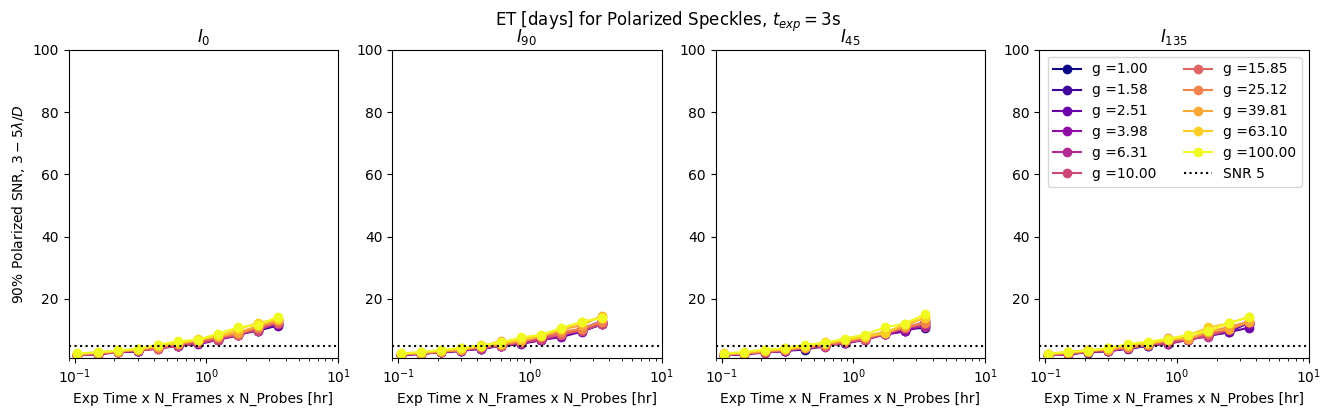

In [48]:
gains = np.logspace(np.log10(1), np.log10(100), 11)
N_FRAMES = 7
s_to_hr = 1 / 3600
single_texp = 3
scale = single_texp / 3
n_coadds = np.logspace(np.log10(3),
                       np.log10(100),
                       11) / scale

# Draw the colormap
n_lines = len(gains)
cmap = plt.get_cmap('plasma')
colors = [cmap(i / (n_lines - 1)) for i in range(n_lines)]

fig, axs = plt.subplots(ncols=4, figsize=[16, 4])
fig.suptitle("ET [days] for Polarized Speckles, "+r"$t_{exp}=$"+f"{single_texp}s")
for gain, color in tqdm(zip(gains, colors), desc="Running Experment for Different Gains"):

    mean_Qs = []
    mean_Us = []
    mean_DoLPs = []

    
    # Re-initialize detector
    emccd_keywords ={'em_gain':gain,
                     'cr_rate':cr_rate}
    detector = instrument.CorgiDetector(emccd_keywords,
                                        photon_counting=False)
    
    I0_snr = []
    I90_snr = []
    I45_snr = []
    I135_snr = []
    
    for i, n_coadd in enumerate(n_coadds):

        N_COADDS = int(n_coadd)
        
        I0s = []
        I90s = []
        I45s = []
        I135s = []
        
        for j in range(N_FRAMES):
            I0 = 0
            I90 = 0
            I45 = 0
            I135 = 0
    
            for _ in range(N_COADDS):
                
                # Re-sample scene from flux map
                sim_scene = detector.generate_detector_image(sim_scene_Q, single_texp)
                I0 += sim_scene.image_on_detector.data[0]
                I90 += sim_scene.image_on_detector.data[1]
                
                # Re-sample scene from flux map
                sim_scene = detector.generate_detector_image(sim_scene_U, single_texp)
                I45 += sim_scene.image_on_detector.data[0]
                I135 += sim_scene.image_on_detector.data[1]

            I0s.append(I0)
            I90s.append(I90)
            I45s.append(I45)
            I135s.append(I135)

        # Get mean and variance
        I0 = np.nanmean(I0s, axis=0)
        I90 = np.nanmean(I90s, axis=0)
        I45 = np.nanmean(I45s, axis=0)
        I135 = np.nanmean(I135s, axis=0)

        var_I0 = np.nanvar(I0s, axis=0)
        var_I90 = np.nanvar(I90s, axis=0)
        var_I45 = np.nanvar(I45s, axis=0)
        var_I135 = np.nanvar(I135s, axis=0)

        I0 /= np.sqrt(var_I0)
        I90 /= np.sqrt(var_I90)
        I45 /= np.sqrt(var_I45)
        I135 /= np.sqrt(var_I135)

        I0_snr.append(np.nanpercentile(I0[mask==1], 90))
        I90_snr.append(np.nanpercentile(I90[mask==1], 90))
        I45_snr.append(np.nanpercentile(I45[mask==1], 90))
        I135_snr.append(np.nanpercentile(I135[mask==1], 90))

    # Begin plotting standard deviation of polarized intensity in annulus
    # Multiply by 2 to account for separate Q and U exposures
    axs[0].plot(N_FRAMES * s_to_hr * single_texp * n_coadds * 6, I0_snr, marker="o", label=f"g ={gain:.2f}", color=color)
    axs[1].plot(N_FRAMES * s_to_hr * single_texp * n_coadds * 6, I90_snr, marker="o", label=f"g ={gain:.2f}", color=color)
    axs[2].plot(N_FRAMES * s_to_hr * single_texp * n_coadds * 6, I45_snr, marker="o", label=f"g ={gain:.2f}", color=color)
    axs[3].plot(N_FRAMES * s_to_hr * single_texp * n_coadds * 6, I135_snr, marker="o", label=f"g ={gain:.2f}", color=color)
    
# Params for Q
axs[0].set_ylabel(r"$90\%$"+" Polarized SNR, "+r"$3-5\lambda/D$")
titles = [r"$I_0$",r"$I_{90}$",r"$I_{45}$",r"$I_{135}$"]
for i, ax in enumerate(axs):
    ax.set_title(titles[i])
    ax.set_xscale("log")
    ax.set_xlabel("Exp Time x N_Frames x N_Probes [hr]")
    ax.set_ylim(1, 100)
    ax.set_xlim(9e-2, 10)
    ax.hlines(5, 9e-2, 10, label="SNR 5", linestyle="dotted", color="k")
plt.legend(ncols=2)
plt.show()

In [42]:
gain = 1626.595 
N_COADDS = 3 #int(n_coadds[7])
single_texp = 28 # 56.171 / 2 # .106 # / np.sqrt(5)
N_FRAMES = 7

N_COADDS = int(N_COADDS)
N_FRAMES = int(N_FRAMES)

# mostly for debugging

titles = [r"$I_0$",r"$I_{90}$",r"$I_{45}$",r"$I_{135}$"]
emccd_keywords ={'em_gain':gain,
                 'cr_rate':cr_rate}

detector = instrument.CorgiDetector(emccd_keywords,
                                    photon_counting=False)

N_FRAMES = int(N_FRAMES)

I0s = []
I90s = []
I45s = []
I135s = []

for x in range(N_FRAMES):
    
    I0 = 0.
    I90 = 0.
    I45 = 0.
    I135 = 0.

    for _ in range(N_COADDS):
        
        # Re-sample scene from flux map
        sim_scene = detector.generate_detector_image(sim_scene_Q, single_texp)
        I0 += sim_scene.image_on_detector.data[0].astype(float)
        I90 += sim_scene.image_on_detector.data[1].astype(float)
        
        # Re-sample scene from flux map
        sim_scene = detector.generate_detector_image(sim_scene_U, single_texp)
        I45 += sim_scene.image_on_detector.data[0].astype(float)
        I135 += sim_scene.image_on_detector.data[1].astype(float)
    
    I0s.append(I0)
    I90s.append(I90)
    I45s.append(I45)
    I135s.append(I135)

# Get mean and variance
I0 = np.nanmean(I0s, axis=0)
I90 = np.nanmean(I90s, axis=0)
I45 = np.nanmean(I45s, axis=0)
I135 = np.nanmean(I135s, axis=0)

var_I0 = np.nanvar(I0s, axis=0)
var_I90 = np.nanvar(I90s, axis=0)
var_I45 = np.nanvar(I45s, axis=0)
var_I135 = np.nanvar(I135s, axis=0)

I0 /= np.sqrt(var_I0)
I90 /= np.sqrt(var_I90)
I45 /= np.sqrt(var_I45)
I135 /= np.sqrt(var_I135)
Is = [I0, I90, I45, I135]

In [43]:
single_texp

28

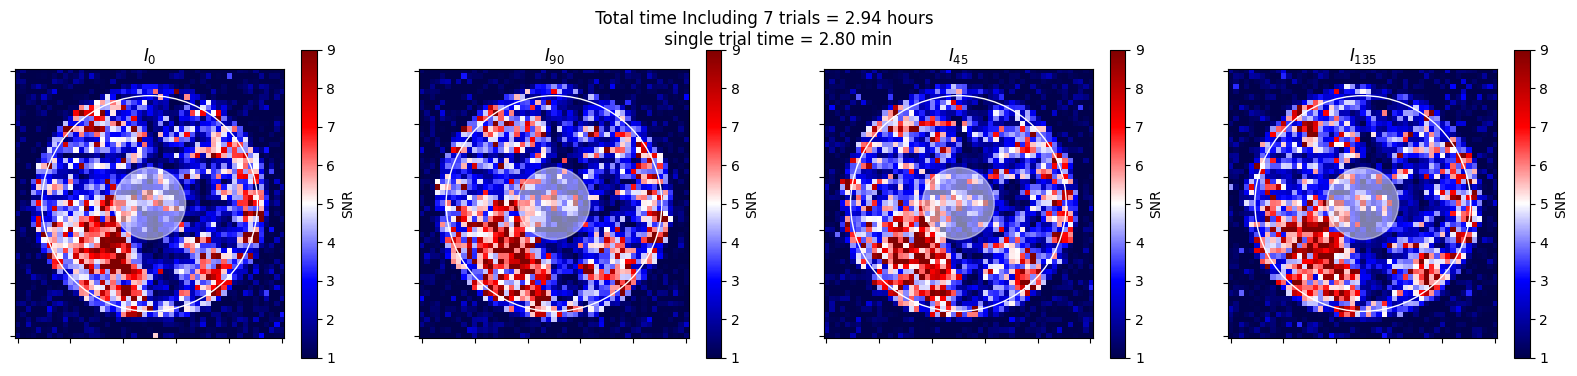

In [44]:
plt.figure(figsize=[20, 4])
plt.suptitle(f" Total time Including {N_FRAMES} trials = {(N_COADDS * N_FRAMES * single_texp * 2 * 9)/60/60:.2f} hours \n \
    single trial time = {N_COADDS * single_texp * 2 / 60:.2f} min")
for i, im in enumerate(Is):
    plt.subplot(1,4,i+1)
    plt.title(titles[i])
    plt.imshow(im, cmap="seismic", vmax=9, vmin=1)
    plt.colorbar(label="SNR")
    plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
    plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
    IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
    OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")
    ax = plt.gca()
    ax.add_patch(IWA)
    ax.add_patch(OWA)
plt.show()